[Sascha Spors](https://orcid.org/0000-0001-7225-9992),
Professorship Signal Theory and Digital Signal Processing,
[Institute of Communications Engineering (INT)](https://www.int.uni-rostock.de/),
Faculty of Computer Science and Electrical Engineering (IEF),
[University of Rostock, Germany](https://www.uni-rostock.de/en/)

# Tutorial Signals and Systems (Signal- und Systemtheorie)

Summer Semester 2021 (Bachelor Course #24015)

- lecture: https://github.com/spatialaudio/signals-and-systems-lecture
- tutorial: https://github.com/spatialaudio/signals-and-systems-exercises

WIP...
The project is currently under heavy development while adding new material for the summer semester 2021

Feel free to contact lecturer [frank.schultz@uni-rostock.de](https://orcid.org/0000-0002-3010-0294)

# Exercise 8: Discrete-Time Convolution

In [1]:
import matplotlib.pyplot as plt
import numpy as np
#from matplotlib.ticker import MaxNLocator
#from scipy import signal

0.015707963267948967 400.0


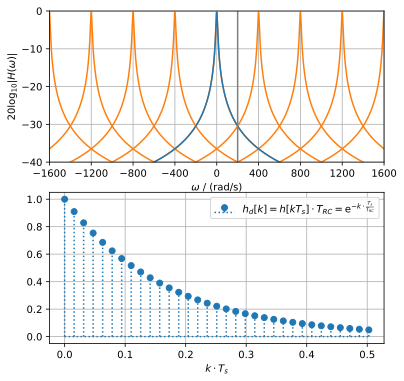

In [2]:
# we create a undersampled and windowed impulse response of a RC-circuit lowpass
TRC = 1/6  # time constant in s
wRC = 1/TRC  # cutoff angular frequency in rad/s

ws = 200/3*wRC  # sampling angular frequency in rad/s, this yields aliasing!!
fs = ws/(2*np.pi)  # sampling frequency in Hz
Ts = 1/fs  # sampling intervall s

w = np.linspace(-10*ws, ws*10, 2**11)  # angular frequency in rad/s
s = 1j*w  # laplace variable along im-axis in rad/s
H = 1 / (s/wRC + 1)  # frequency response

k = np.arange(np.int32(np.ceil(0.5/Ts)+1))  # sample index
h = (1/TRC * np.exp(-k*Ts/TRC))  # sampled impulse response, windowed!!
# normalize to achieve h[k=0] = 1, cf. convolution_ct_example2_AF3B15E0D3.ipynb
h *= TRC
Nh = h.size
kh = 0  # start of impulse response

plt.figure(figsize=(6, 6))
plt.subplot(2, 1, 1)
for nu in np.arange(-4, 5, 1):
    plt.plot(w+nu*ws, 20*np.log10(np.abs(H)), 'C1')
plt.plot(w, 20*np.log10(np.abs(H)))
plt.plot([ws/2, ws/2], [-40, 0], 'C7')
plt.xticks(ws*np.arange(-4, 5, 1))
plt.xlim(-4*ws, +4*ws)
plt.ylim(-40, 0)
plt.xlabel(r'$\omega$ / (rad/s)')
plt.ylabel(r'$20 \log_{10} |H(\omega)|$')
plt.grid(True)
plt.subplot(2, 1, 2)
plt.stem(k*Ts, h, use_line_collection=True,
         linefmt='C0:', markerfmt='C0o', basefmt='C0:',
         label=r'$h_d[k] =  h[k T_s] \cdot T_{RC} = \mathrm{e}^{-k\cdot\frac{T_s}{T_{RC}}}$')
plt.xlabel(r'$k \cdot T_s$')
plt.legend()
plt.grid(True)

print(Ts, ws)

In [3]:
# signal
x = 2*np.ones(np.int32(np.ceil(2 / Ts)))  # non-zero elements
Nx = x.size
kx = np.int32(np.ceil(1/Ts))  # start index for first non-zero entry

In [4]:
# discrete-time convolution
Ny = Nx+Nh-1
ky = kx+kh
y = np.convolve(x, h)

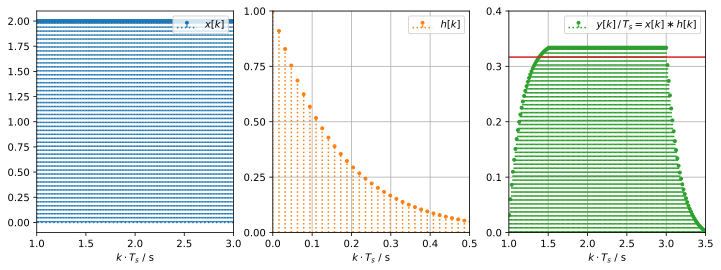

In [5]:
plt.figure(figsize=(12, 4))

k = np.arange(kx, kx+Nx)
ax = plt.subplot(1, 3, 1)
plt.stem(k*Ts, x, use_line_collection=True,
         linefmt='C0:', markerfmt='C0.', basefmt='C0:',
         label=r'$x[k]$')
plt.xlim(1, 3)
plt.xlabel(r'$k \cdot T_s$ / s')
plt.legend(loc='upper right')

k = np.arange(kh, kh+Nh)
ax = plt.subplot(1, 3, 2)
plt.stem(k*Ts, h, use_line_collection=True,
         linefmt='C1:', markerfmt='C1.', basefmt='C1:',
         label=r'$h[k]$')
plt.xlim(0, 0.5)
plt.ylim(0, 1)
plt.yticks(np.arange(0, 1.25, 0.25))
plt.xlabel(r'$k \cdot T_s$ / s')
plt.legend(loc='upper right')
plt.grid(True)

k = np.arange(ky, ky+Ny)
ax = plt.subplot(1, 3, 3)
plt.stem(k*Ts, y*Ts, use_line_collection=True,
         linefmt='C2:', markerfmt='C2.', basefmt='C2:',
         label=r'$y[k]\,/\,T_s = x[k]\ast h[k]$')
tmp = (1-np.exp(-3))/3
plt.plot([1, 3.5], [tmp, tmp], 'C3')
plt.xlim(1, 3.5)
plt.ylim(0, 0.4)
plt.yticks(np.arange(0, 0.5, 0.1))
plt.xlabel(r'$k \cdot T_s$ / s')
plt.legend(loc='upper right')
plt.grid(True)
plt.savefig('convolution_discrete_pt1_xhy.pdf')

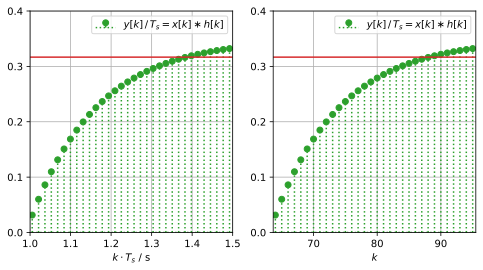

In [6]:
plt.figure(figsize=(8, 4))

k = np.arange(ky, ky+Ny)
ax = plt.subplot(1, 2, 1)
plt.stem(k*Ts, y*Ts, use_line_collection=True,
         linefmt='C2:', markerfmt='C2o', basefmt='C2:',
         label=r'$y[k]\,/\,T_s = x[k]\ast h[k]$')
tmp = (1-np.exp(-3))/3
plt.plot([1, 3.5], [tmp, tmp], 'C3')
plt.xlim(1, 1.5)
plt.ylim(0, 0.4)
plt.yticks(np.arange(0, 0.5, 0.1))
plt.xlabel(r'$k \cdot T_s$ / s')
plt.legend(loc='upper right')
plt.grid(True)

ax = plt.subplot(1, 2, 2)
plt.stem(k, y*Ts, use_line_collection=True,
         linefmt='C2:', markerfmt='C2o', basefmt='C2:',
         label=r'$y[k]\,/\,T_s = x[k]\ast h[k]$')
tmp = (1-np.exp(-3))/3
plt.plot([1/Ts, 3.5/Ts], [tmp, tmp], 'C3')
plt.xlim(1/Ts, 1.5/Ts)
plt.ylim(0, 0.4)
plt.yticks(np.arange(0, 0.5, 0.1))
plt.xlabel(r'$k$')
plt.legend(loc='upper right')
plt.grid(True)

plt.savefig('convolution_discrete_pt1_y_over_kt_zoom.pdf')

## Copyright

This tutorial is provided as Open Educational Resource (OER), to be found at
https://github.com/spatialaudio/signals-and-systems-exercises
accompanying the OER lecture
https://github.com/spatialaudio/signals-and-systems-lecture.
Both are licensed under a) the Creative Commons Attribution 4.0 International
License for text and graphics and b) the MIT License for source code.
Please attribute material from the tutorial as *Frank Schultz,
Continuous- and Discrete-Time Signals and Systems - A Tutorial Featuring
Computational Examples, University of Rostock* with
``main file, github URL, commit number and/or version tag, year``.